# speech emotion recognition

ravdess speech dataset, 8 emotions. a random forest baseline plus a small cnn on log mel spectrograms.

In [1]:
import os, glob, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('device:', device)

device: mps


In [ ]:
DATA_DIR = 'emotion_speech_dataset'

emo_map = {1:'neutral',2:'calm',3:'happy',4:'sad',5:'angry',6:'fearful',7:'disgust',8:'surprised'}

files = sorted(glob.glob(os.path.join(DATA_DIR, 'Actor_*', '*.wav')))

rows = []
for fp in files:
    parts = os.path.basename(fp).replace('.wav','').split('-')
    emo, inten, actor = int(parts[2]), int(parts[3]), int(parts[6])
    rows.append({'filepath':fp, 'emotion':emo_map[emo],
                 'intensity':'strong' if inten==2 else 'normal',
                 'actor':actor, 'gender':'male' if actor%2==1 else 'female'})
df = pd.DataFrame(rows)
print(len(df), 'files')
df.head()

1440 files


,filepath,emotion,intensity,actor,gender
0,emotion_speech_dataset/Actor_01/03-01-01-01-01...,neutral,normal,1,male
1,emotion_speech_dataset/Actor_01/03-01-01-01-01...,neutral,normal,1,male
2,emotion_speech_dataset/Actor_01/03-01-01-01-02...,neutral,normal,1,male
3,emotion_speech_dataset/Actor_01/03-01-01-01-02...,neutral,normal,1,male
4,emotion_speech_dataset/Actor_01/03-01-02-01-01...,calm,normal,1,male


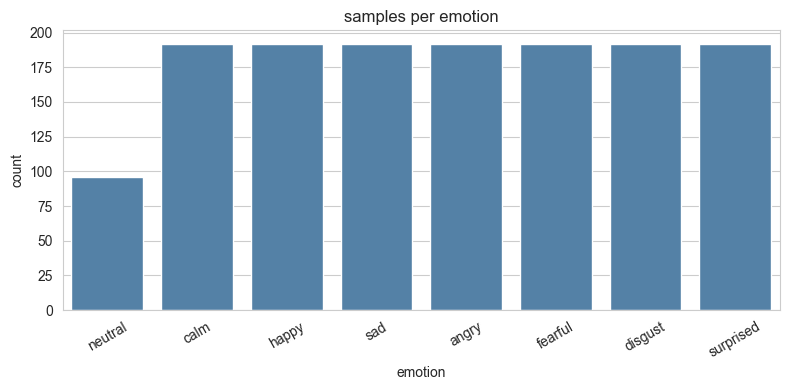

emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


In [4]:
order = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='emotion', order=order, color='steelblue')
plt.title('samples per emotion'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()
print(df.emotion.value_counts())

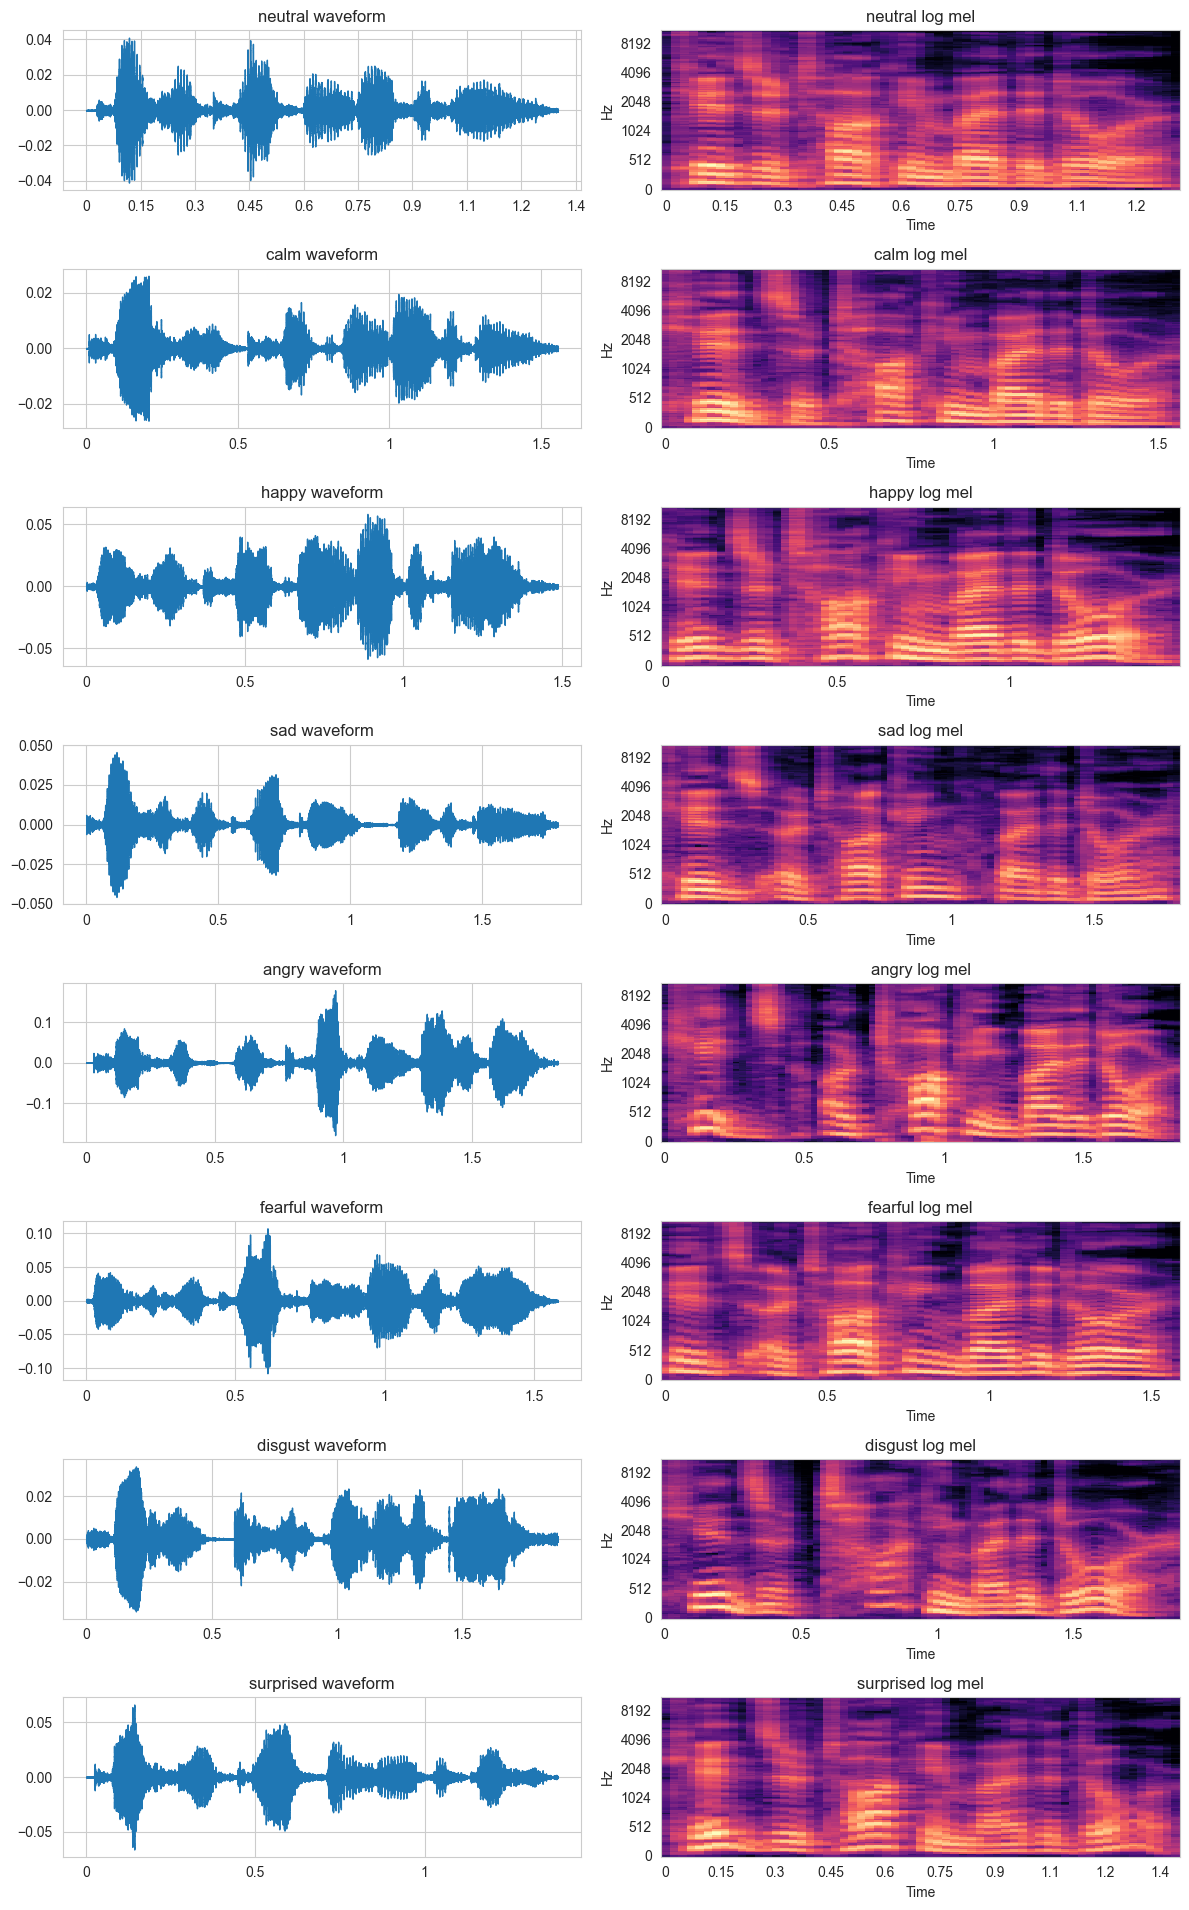

In [5]:
# one clip per emotion, waveform next to its log mel spectrogram
fig, ax = plt.subplots(len(order), 2, figsize=(12, 2.4*len(order)))
for i, emo in enumerate(order):
    fp = df[df.emotion==emo].filepath.iloc[0]
    y, sr = librosa.load(fp, sr=22050, mono=True)
    yt, _ = librosa.effects.trim(y, top_db=25)
    librosa.display.waveshow(yt, sr=sr, ax=ax[i,0])
    ax[i,0].set_title(f'{emo} waveform'); ax[i,0].set_xlabel('')
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=yt, sr=sr, n_mels=128), ref=np.max)
    librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel', ax=ax[i,1])
    ax[i,1].set_title(f'{emo} log mel')
plt.tight_layout(); plt.show()

## actor based split

In [6]:
actors = sorted(df.actor.unique())
gend = ['M' if a%2==1 else 'F' for a in actors]

train_act, tmp_act = train_test_split(actors, test_size=6, stratify=gend, random_state=SEED)
tmp_gend = ['M' if a%2==1 else 'F' for a in tmp_act]
val_act, test_act = train_test_split(tmp_act, test_size=3, stratify=tmp_gend, random_state=SEED)

split_of = {a:'train' for a in train_act}
split_of.update({a:'val' for a in val_act})
split_of.update({a:'test' for a in test_act})
df['split'] = df.actor.map(split_of)

print('train actors', sorted(train_act))
print('val actors  ', sorted(val_act))
print('test actors ', sorted(test_act))
print(df.groupby('split').size())

train actors [1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 17, 18, 19, 20, 21, 22, 24]
val actors   [8, 15, 23]
test actors  [5, 14, 16]
split
test      180
train    1080
val       180
dtype: int64


## feature extraction

In [7]:
SR = 22050
DUR = 3.0
N_MELS = 128
N_FFT = 1024
HOP = 512
TGT = int(SR*DUR)

def load_fixed(fp):
    y, _ = librosa.load(fp, sr=SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=25)
    if len(y) < TGT:
        y = np.pad(y, (0, TGT-len(y)))
    else:
        s = (len(y)-TGT)//2
        y = y[s:s+TGT]
    return y

def to_logmel(y):
    m = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    return librosa.power_to_db(m, ref=np.max).astype(np.float32)

def mfcc_stats(y):
    mf = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=40)
    return np.concatenate([mf.mean(axis=1), mf.std(axis=1)]).astype(np.float32)

CACHE = 'emotion_feats.npz'
if os.path.exists(CACHE):
    d = np.load(CACHE, allow_pickle=True)
    mel_X, mfcc_X, ok_paths = d['mel'], d['mfcc'], d['paths']
    print('loaded cached features', mel_X.shape)
else:
    mel_X, mfcc_X, ok_paths, bad = [], [], [], []
    for fp in df.filepath:
        try:
            y = load_fixed(fp)
            mel_X.append(to_logmel(y))
            mfcc_X.append(mfcc_stats(y))
            ok_paths.append(fp)
        except Exception as e:
            bad.append(fp); print('skip', fp, e)
    mel_X = np.stack(mel_X); mfcc_X = np.stack(mfcc_X); ok_paths = np.array(ok_paths)
    np.savez(CACHE, mel=mel_X, mfcc=mfcc_X, paths=ok_paths)
    print('extracted', mel_X.shape, '|', len(bad), 'skipped')

# realign df to the files that actually loaded
df = df.set_index('filepath').loc[ok_paths].reset_index()
print('mel', mel_X.shape, 'mfcc', mfcc_X.shape)

loaded cached features (1440, 128, 130)
mel (1440, 128, 130) mfcc (1440, 80)


## model 1: random forest baseline

In [8]:
classes = order
cls_idx = {c:i for i,c in enumerate(classes)}
y_all = df.emotion.map(cls_idx).values

tr = (df.split=='train').values
va = (df.split=='val').values
te = (df.split=='test').values

rf = RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1)
rf.fit(mfcc_X[tr], y_all[tr])
rf_pred = rf.predict(mfcc_X[te])
rf_acc = accuracy_score(y_all[te], rf_pred)
print('rf test accuracy:', round(rf_acc, 4))

rf test accuracy: 0.4389


## model 2: cnn on log mel spectrograms

In [ ]:
LR = 1e-3
WD = 1e-4
BATCH = 32
EPOCHS = 40

mu, sd = mel_X[tr].mean(), mel_X[tr].std()
mel_N = (mel_X - mu) / sd

class MelDS(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32); self.y = y.astype(np.int64)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]).unsqueeze(0), self.y[i]

tr_dl = DataLoader(MelDS(mel_N[tr], y_all[tr]), batch_size=BATCH, shuffle=True)
va_dl = DataLoader(MelDS(mel_N[va], y_all[va]), batch_size=BATCH)
te_dl = DataLoader(MelDS(mel_N[te], y_all[te]), batch_size=BATCH)

def blk(i, o):
    return nn.Sequential(nn.Conv2d(i,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))

class EmoCNN(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        self.feat = nn.Sequential(blk(1,32), blk(32,64), blk(64,128), blk(128,128))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(128, n_cls))
    def forward(self, x):
        return self.head(self.feat(x))

cnt = np.bincount(y_all[tr], minlength=len(classes)).astype(np.float32)
w = cnt.sum() / (len(classes) * cnt)
class_w = torch.tensor(w, dtype=torch.float32, device=device)
print('class weights:', dict(zip(classes, w.round(2))))

class weights: {'neutral': 1.88, 'calm': 0.94, 'happy': 0.94, 'sad': 0.94, 'angry': 0.94, 'fearful': 0.94, 'disgust': 0.94, 'surprised': 0.94}


class weights are inverse frequency from the train counts, so the smaller neutral class contributes as much to the loss as the full size emotions.

In [ ]:
model = EmoCNN(len(classes)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
crit = nn.CrossEntropyLoss(weight=class_w)

hist = {'tr_loss':[], 'va_loss':[], 'va_acc':[]}
best_acc = 0.0

for ep in range(1, EPOCHS+1):
    model.train()
    tl = 0.0
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward(); opt.step()
        tl += loss.item()*len(yb)
    tl /= tr.sum()

    model.eval()
    vl, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in va_dl:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            vl += crit(out, yb).item()*len(yb)
            correct += (out.argmax(1)==yb).sum().item()
    vl /= va.sum(); vacc = correct/va.sum()
    hist['tr_loss'].append(tl); hist['va_loss'].append(vl); hist['va_acc'].append(vacc)

    if vacc > best_acc:
        best_acc = vacc
        torch.save(model.state_dict(), 'best_emotion_cnn.pt')
    if ep==1 or ep%5==0:
        print(f'ep {ep:2d}  tr_loss {tl:.3f}  va_loss {vl:.3f}  va_acc {vacc:.3f}')

print('best val acc:', round(best_acc, 4))

ep  1  tr_loss 1.899  va_loss 2.078  va_acc 0.200


ep  5  tr_loss 1.369  va_loss 1.481  va_acc 0.439


ep 10  tr_loss 1.018  va_loss 1.464  va_acc 0.433


ep 15  tr_loss 0.773  va_loss 1.786  va_acc 0.467


ep 20  tr_loss 0.490  va_loss 2.397  va_acc 0.317


ep 25  tr_loss 0.346  va_loss 1.940  va_acc 0.378


ep 30  tr_loss 0.193  va_loss 5.015  va_acc 0.111


ep 35  tr_loss 0.129  va_loss 3.282  va_acc 0.317


ep 40  tr_loss 0.088  va_loss 3.434  va_acc 0.278
best val acc: 0.55


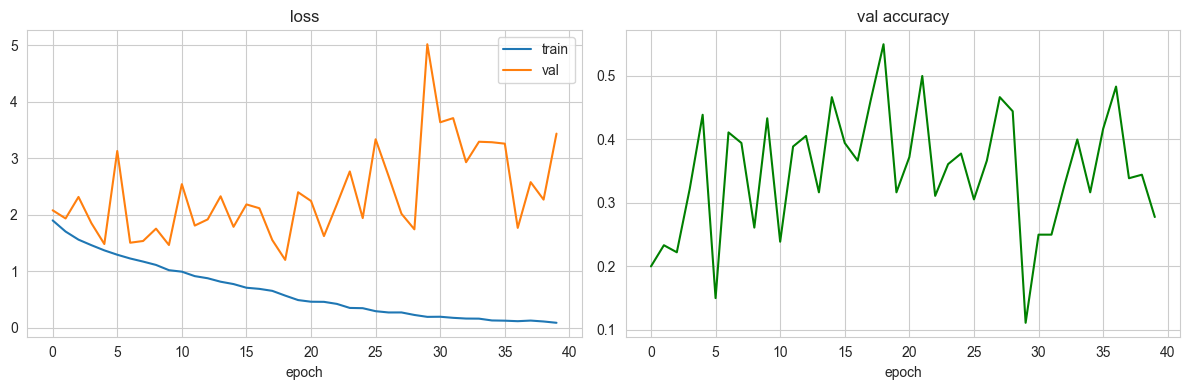

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(hist['tr_loss'], label='train'); ax[0].plot(hist['va_loss'], label='val')
ax[0].set_title('loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist['va_acc'], color='green')
ax[1].set_title('val accuracy'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

## evaluation

In [12]:
model.load_state_dict(torch.load('best_emotion_cnn.pt', map_location=device))
model.eval()

cnn_pred = []
with torch.no_grad():
    for xb, _ in te_dl:
        cnn_pred.append(model(xb.to(device)).argmax(1).cpu().numpy())
cnn_pred = np.concatenate(cnn_pred)
y_te = y_all[te]

cnn_acc = accuracy_score(y_te, cnn_pred)
print('rf  test accuracy:', round(rf_acc, 4))
print('cnn test accuracy:', round(cnn_acc, 4))

rf  test accuracy: 0.4389
cnn test accuracy: 0.4556


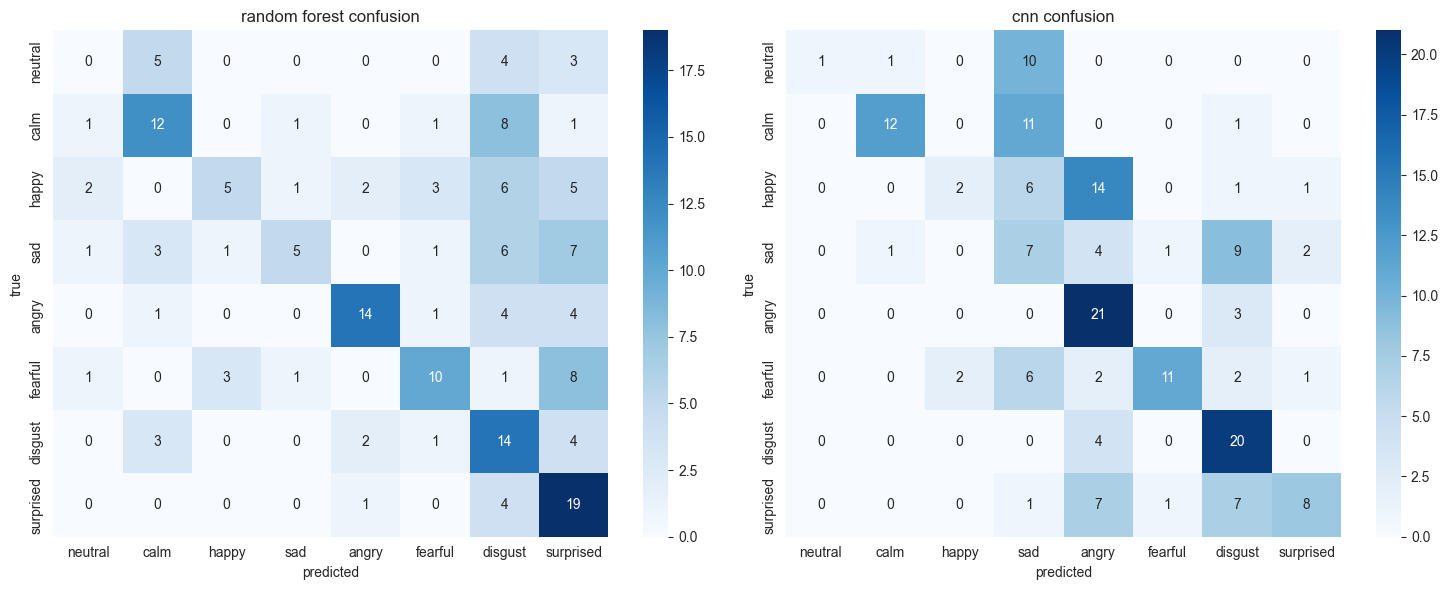

=== random forest ===
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00        12
        calm       0.50      0.50      0.50        24
       happy       0.56      0.21      0.30        24
         sad       0.62      0.21      0.31        24
       angry       0.74      0.58      0.65        24
     fearful       0.59      0.42      0.49        24
     disgust       0.30      0.58      0.39        24
   surprised       0.37      0.79      0.51        24

    accuracy                           0.44       180
   macro avg       0.46      0.41      0.39       180
weighted avg       0.49      0.44      0.42       180

=== cnn ===
              precision    recall  f1-score   support

     neutral       1.00      0.08      0.15        12
        calm       0.86      0.50      0.63        24
       happy       0.50      0.08      0.14        24
         sad       0.17      0.29      0.22        24
       angry       0.40      0.88      0.55 

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15,6))
for a, (name, pred) in zip(ax, [('random forest', rf_pred), ('cnn', cnn_pred)]):
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=a)
    a.set_title(f'{name} confusion'); a.set_xlabel('predicted'); a.set_ylabel('true')
plt.tight_layout(); plt.show()

print('=== random forest ===')
print(classification_report(y_te, rf_pred, target_names=classes))
print('=== cnn ===')
print(classification_report(y_te, cnn_pred, target_names=classes))

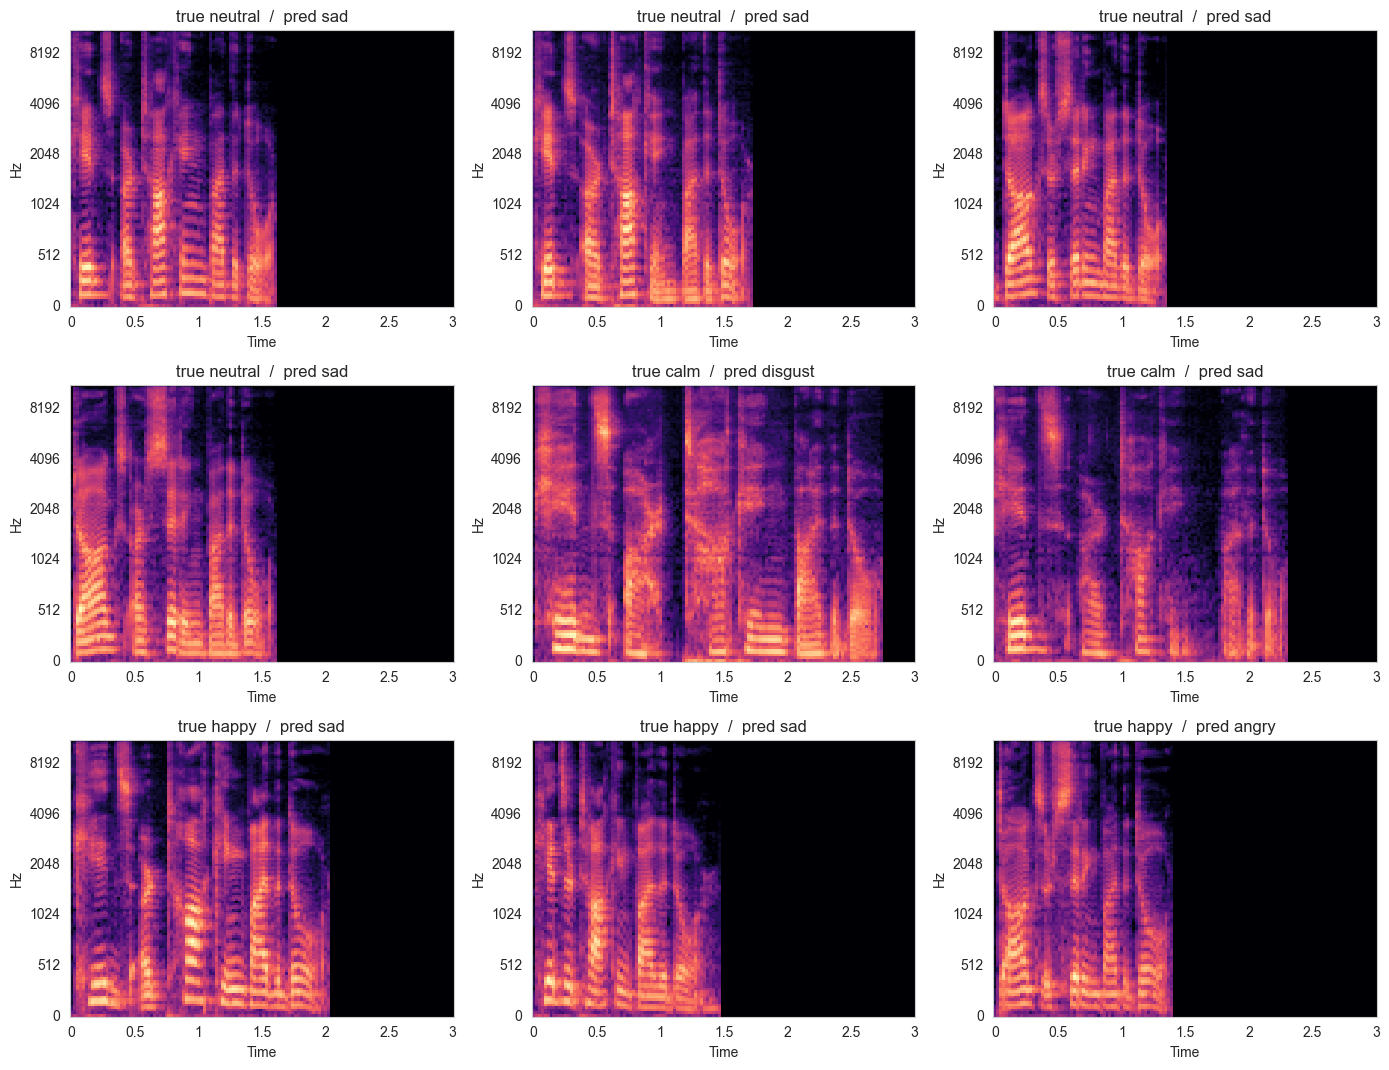

In [ ]:
te_idx = np.where(te)[0]
wrong_mask = cnn_pred != y_te
show = te_idx[wrong_mask][:9]

cols = 3; rows = int(np.ceil(len(show)/cols))
fig, ax = plt.subplots(rows, cols, figsize=(14, 3.6*rows))
ax = np.array(ax).reshape(-1)
for k, gi in enumerate(show):
    librosa.display.specshow(mel_X[gi], sr=SR, hop_length=HOP,
                             x_axis='time', y_axis='mel', ax=ax[k])
    li = np.where(te_idx==gi)[0][0]
    ax[k].set_title(f'true {classes[y_te[li]]}  /  pred {classes[cnn_pred[li]]}')
for k in range(len(show), len(ax)): ax[k].axis('off')
plt.tight_layout(); plt.show()

## wrap up

test set is 3 held out actors, 180 clips, no actor seen in training.

- random forest on mfcc stats: 0.44 test accuracy
- cnn on log mel spectrograms: 0.46 test accuracy

both land around 45 percent for 8 classes. chance is 12.5 percent so both clearly learn something, but this is a hard setup: actor independent splitting means the model cannot lean on familiar voices, and there are only 18 training actors.

most confused pairs from the cnn confusion matrix:

- happy predicted as angry (14 clips). both are high arousal, loud and fast, so the spectrograms look alike.
- calm and neutral predicted as sad (11 and 10 clips). all three are low energy and flat in pitch, the quiet emotions blur together.

the cnn also overfits fast. train loss drops near zero while val loss climbs, which is why we keep the best checkpoint by val accuracy rather than the last epoch.

what would help in production: more speakers for real actor independent generalization, data augmentation with pitch and speed perturbation to widen the training distribution, and for real conversations speaker diarization to segment who is talking before classifying emotion.
